In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [38]:
df = pd.read_excel('../Dataset/Credir_Card_Bank.xlsx')

In [39]:
df

,Customer_ID,Age,Gender,Employment_Type,Occupation,Monthly_Income,Annual_Income,Credit_Score,Years_With_Bank,Existing_Credit_Cards,...,Credit_Utilization,Credit_History_Years,Missed_Payments,Late_Payment_Count,Number_of_Defaults,Residential_Status,PAN_Verified,KYC_Status,Fraud_Flag,Credit_Limit
0,CUST00001,41,Female,Salaried,Sales Executive,140273,1683276,811,4,4,...,34,11,0,8,0,Rent,Yes,Complete,No,1373925
1,CUST00002,23,Male,Self-Employed,Business Owner,209521,2514252,837,12,2,...,71,20,3,3,0,Own,Yes,Complete,No,1902449
2,CUST00003,45,Female,Salaried,Designer,47682,572184,679,2,6,...,88,12,5,2,0,Rent,Yes,Complete,No,1165913
3,CUST00004,39,Male,Salaried,Doctor,214966,2579592,660,5,0,...,66,4,3,5,0,Rent,Yes,Complete,No,1869491
4,CUST00005,58,Male,Self-Employed,Designer,30051,360612,589,18,0,...,70,1,4,2,0,Own,Yes,Complete,No,825275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,CUST04996,48,Male,Salaried,Doctor,55078,660936,824,12,1,...,91,7,4,4,0,Rent,Yes,Complete,No,1156917
4996,CUST04997,59,Female,Self-Employed,Accountant,107040,1284480,840,0,1,...,28,22,1,6,0,Own,Yes,Complete,No,1458578
4997,CUST04998,26,Female,Salaried,Doctor,168754,2025048,632,19,0,...,38,11,3,1,0,Rent,Yes,Complete,No,1342610
4998,CUST04999,42,Male,Salaried,Manager,197110,2365320,734,9,2,...,15,3,2,2,0,Own,Yes,Complete,No,1868828


# Analyze Customers with Defaults

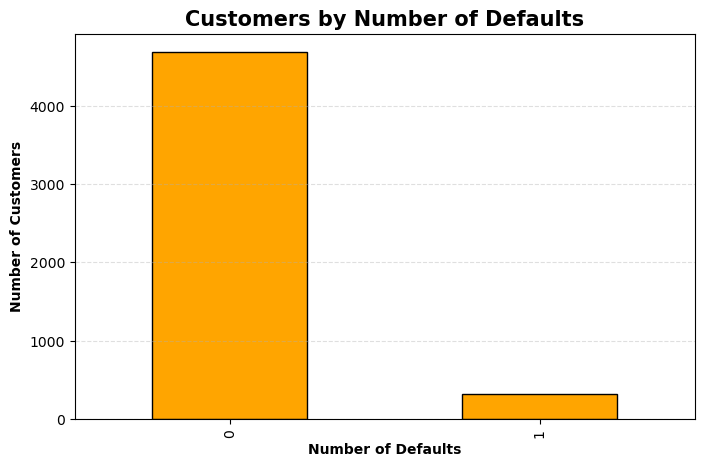

In [40]:
defaults = df.groupby('Number_of_Defaults')['Customer_ID'].count()

defaults.plot(kind='bar',color='Orange',edgecolor='black',figsize=(8,5))

plt.title("Customers by Number of Defaults", fontsize=15, fontweight='bold')
plt.xlabel("Number of Defaults", fontweight='bold')
plt.ylabel("Number of Customers", fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

# Analyze Missed Payments

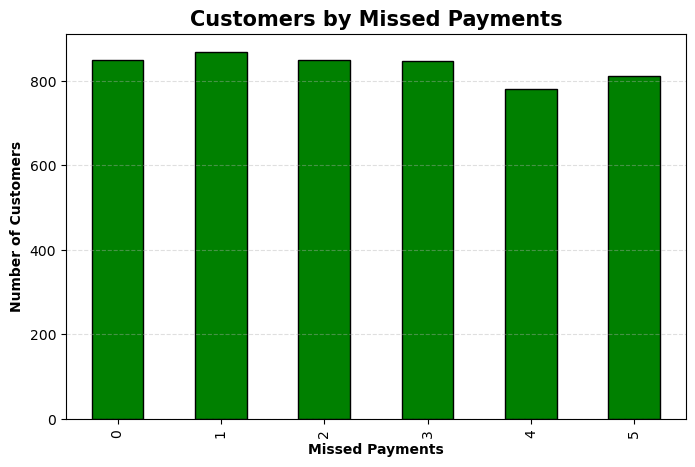

In [41]:
missed = df.groupby('Missed_Payments')['Customer_ID'].count()

missed.plot(kind='bar',color='green',edgecolor='black',figsize=(8,5))

plt.title("Customers by Missed Payments", fontsize=15, fontweight='bold')
plt.xlabel("Missed Payments", fontweight='bold')
plt.ylabel("Number of Customers", fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

# Analyze Late Payment Trends

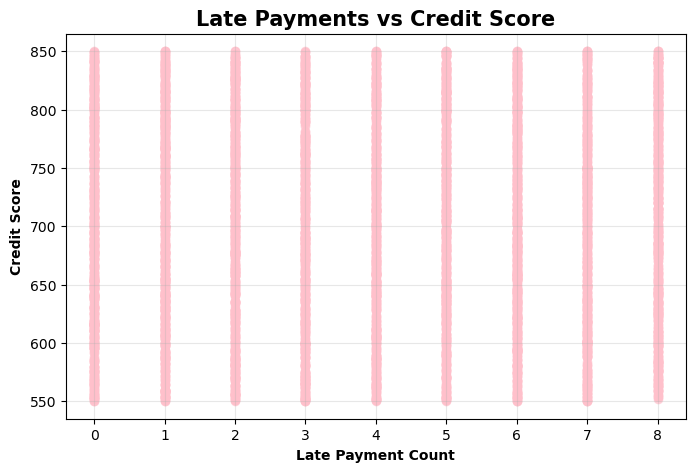

In [44]:
late = df.groupby('Late_Payment_Count')['Customer_ID'].count()

plt.figure(figsize=(8,5))

plt.scatter(df['Late_Payment_Count'],df['Credit_Score'],color='pink',alpha=0.6)

plt.title("Late Payments vs Credit Score",fontsize=15,fontweight='bold')

plt.xlabel("Late Payment Count",fontweight='bold')

plt.ylabel("Credit Score",fontweight='bold')

plt.grid(alpha=0.3)

plt.show()

# Identify High-Risk Customer Groups

In [45]:
high_risk = df[
    (df['Credit_Score'] < 600) &
    (df['Missed_Payments'] > 2) &
    (df['Number_of_Defaults'] > 0)]

high_risk.head()

,Customer_ID,Age,Gender,Employment_Type,Occupation,Monthly_Income,Annual_Income,Credit_Score,Years_With_Bank,Existing_Credit_Cards,...,Credit_Utilization,Credit_History_Years,Missed_Payments,Late_Payment_Count,Number_of_Defaults,Residential_Status,PAN_Verified,KYC_Status,Fraud_Flag,Credit_Limit
25,CUST00026,31,Female,Salaried,Doctor,141177,1694124,581,10,4,...,58,1,4,3,1,Rent,Yes,Complete,No,1073580
38,CUST00039,26,Female,Salaried,Software Engineer,198180,2378160,558,7,5,...,92,10,3,6,1,Own,Yes,Complete,No,1431741
92,CUST00093,49,Male,Self-Employed,Designer,164812,1977744,571,11,5,...,46,8,3,3,1,Own,Yes,Complete,No,1372071
128,CUST00129,40,Male,Self-Employed,Designer,211809,2541708,588,7,4,...,18,7,5,8,1,Rent,Yes,Complete,No,1417795
225,CUST00226,32,Female,Self-Employed,Accountant,34567,414804,587,13,1,...,5,11,4,3,1,Rent,Yes,Complete,No,595223


# Compare Risk Across Occupations

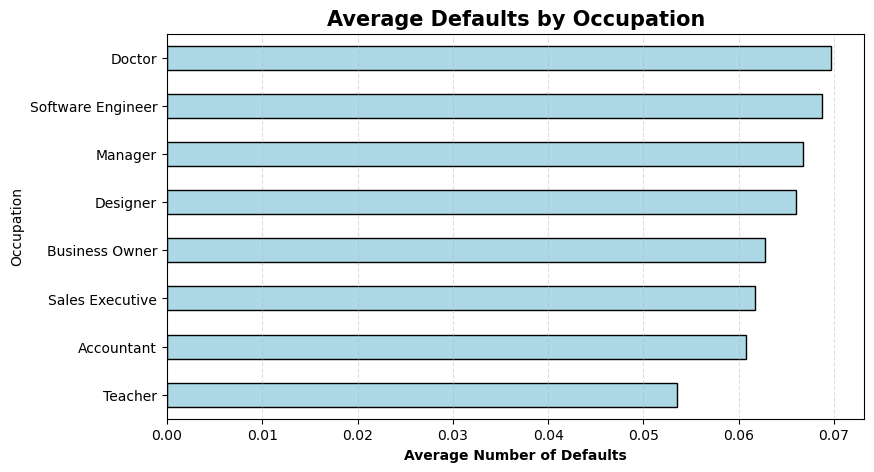

In [50]:
occupation = df.groupby('Occupation')['Number_of_Defaults'].mean()


occupation.sort_values().plot(kind='barh',color='lightblue',edgecolor='black',figsize=(9,5))

plt.title("Average Defaults by Occupation", fontsize=15, fontweight='bold')
plt.xlabel("Average Number of Defaults", fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.show()

# Compare Risk Across Age Groups

In [47]:
def age_group(age):
    if age >= 18 and age <= 30:
        return "18-30"
    elif age >= 31 and age <= 40:
        return "31-40"
    elif age >= 41 and age <= 50:
        return "41-50"
    else:
        return "51-60"

df['Age_Group'] = df['Age'].apply(age_group)

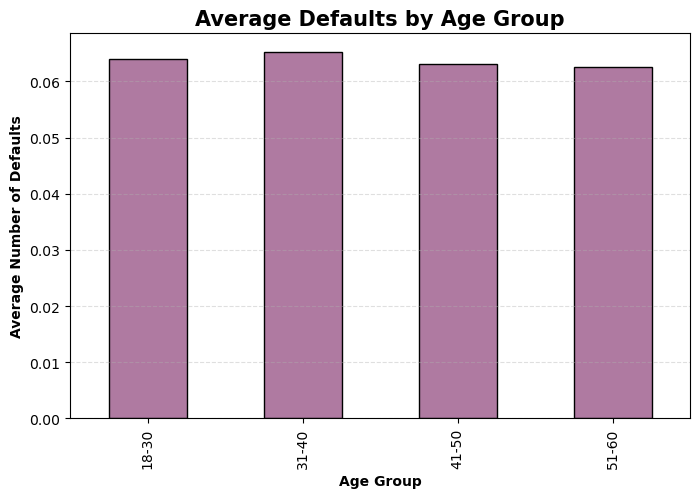

In [48]:
age = df.groupby('Age_Group', observed=True)['Number_of_Defaults'].mean()

age.plot(kind='bar',color='#AF7AA1',edgecolor='black',figsize=(8,5))

plt.title("Average Defaults by Age Group", fontsize=15, fontweight='bold')
plt.xlabel("Age Group", fontweight='bold')
plt.ylabel("Average Number of Defaults", fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

## Overall Business Summary

## Key Findings
### Customers with higher defaults, more missed payments, and frequent late payments represent the highest financial risk.
### Credit score is one of the strongest indicators of customer creditworthiness.
### Payment history provides valuable insight into future repayment behavior.
### Occupation and age group comparisons help identify customer segments with different risk profiles but should not be used in isolation.


## Recommendations
### Prioritize loans for customers with strong credit scores and positive repayment histories.
### Monitor customers with increasing missed or late payments to reduce future defaults.
### Implement risk-based credit policies by combining credit score, payment history, income, and other financial indicators.
### Use the findings to improve customer segmentation, loan approval strategies, and portfolio risk management.